Representar la evolución de las posiciones de las partículas en los primeros 5 segundos y en los últimos 5 segundos.

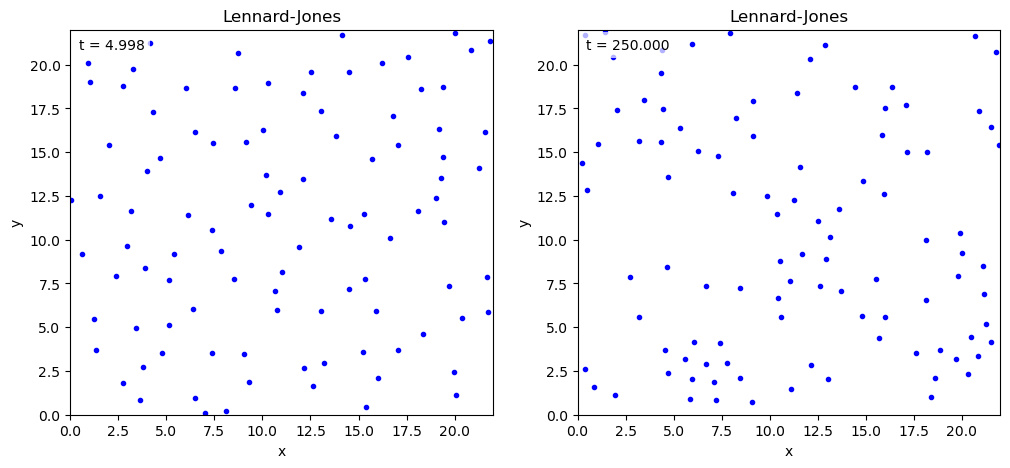

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Cargo los datos de las posiciones de las partícuas desde el fichero generado
Posiciones = np.loadtxt("Posiciones_Atomos_v_x.txt")

# Defino el paso temporal
h = 0.002

# Número de frames equivalentes a 5 segundos
Num_frames = int(5 / h)

# Extraigo las posiciones x e y de cada átomo hasta i_final
# Por la estructura de la matriz, debo extraer los datos dando saltos de 2 en las columnas, ya que la X y la Y están intercaladas
x_in = Posiciones[:Num_frames, 0::2]
y_in = Posiciones[:Num_frames, 1::2]
x_fin = Posiciones[-Num_frames:, 0::2]
y_fin = Posiciones[-Num_frames:, 1::2]
# Matrices de dimensión Nx100

# Creo la figura y los ejes para la animación
fig, ax = plt.subplots(1,2, figsize=(12, 5))
ax[0].set(xlabel="x", ylabel="y", xlim=[0, 22], ylim=[0, 22], title="Lennard-Jones")
ax[1].set(xlabel="x", ylabel="y", xlim=[0, 22], ylim=[0, 22], title="Lennard-Jones")

# Creo las líneas que representan cada átomo
line_in, = ax[0].plot([], [], color = 'blue', marker = 'o', markersize = 3, linestyle = 'None')
line_fin, = ax[1].plot([], [], color = 'blue', marker = 'o', markersize = 3, linestyle = 'None')
# linestyle = 'None' es para que no se dibujen líneas entre los puntos, sino solo los puntos

# Creo un texto para mostrar el tiempo en cada frame
texto_1 = ax[0].text(0.02, 0.95, "", transform=ax[0].transAxes, fontsize=10, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
texto_2 = ax[1].text(0.02, 0.95, "", transform=ax[1].transAxes, fontsize=10, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

# Creo la función de animación
def animate(i):

    t_in= i * h
    t_fin = 245 + (i + 1) * h

    line_in.set_data(x_in[i, :], y_in[i, :])
    line_fin.set_data(x_fin[i, :], y_fin[i, :])

    # Actualizo el texto con el tiempo correspondiente a cada frame
    texto_1.set_text(f"t = {t_in:.3f}")
    texto_2.set_text(f"t = {t_fin:.3f}") 

    return line_in, line_fin, texto_1, texto_2

# Crea una animación usando la función animate
ani = animation.FuncAnimation(fig, animate, frames = Num_frames, interval = 20, blit = True)

ani.save("Lennard_Jones_animacion_v_x.gif", writer='pillow', dpi = 150)
# Guarda la animación como un archivo GIF usando el escritor 'pillow' y dpi es para establecer la calidad de la imagen, siendo que a mayor dpi, mayor calidad y mayor tamaño del archivo GIF generado


Calculo la energía cinética, potencial y total del sistema.

In [11]:
import numpy as np

# Extraigo los datos de las posiciones y velocidades de los ficheros
Posiciones = np.loadtxt("Posiciones_Atomos_v_x.txt")
Velocidades = np.loadtxt("Velocidades_Atomos_v_x.txt")

# Extraigo las posiciones x e y de cada átomo 
x = Posiciones[:, 0::2]
y = Posiciones[:, 1::2]

# Extraigo las velocidades v_x e v_y de cada átomo
v_x = Velocidades[:, 0::2]
v_y = Velocidades[:, 1::2]

# Calculo la energía cinética de cada átomo en cada instante de tiempo
E_cinetica = 0.5 * (v_x**2 + v_y**2)

# Calculo la energía cinética total del sistema en cada instante de tiempo
E_cinetica_total = np.sum(E_cinetica, axis=1)

# Calculo la energía potencial de cada átomo en cada instante de tiempo
E_potencial = np.zeros_like(E_cinetica)

for i in range(x.shape[1]):  # Recorro cada átomo
    for j in range(i + 1, x.shape[1]):  # Recorro los átomos restantes para evitar contar dos veces la misma interacción (i < j)

        # Calculo la distancia entre los átomos i y j teniendo en cuenta las condiciones periódicas de la caja
        dx = abs(x[:, i] - x[:, j])
        dx[dx > 11] = 22.0 - dx[dx > 11]
            
        dy = abs(y[:, i] - y[:, j])
        dy[dy > 11] = 22.0 - dy[dy > 11]

        r_ij = np.sqrt(dx**2 + dy**2)

        # Pongo un filtro para ver cuando 0 < r_ij < 3
        filtro = (r_ij > 0.0) & (r_ij < 3.0)
        # Este filtro es un array de booleanos

        # Calculo la energía potencial de interacción entre los átomos i y j para todos los tiempos a la vez
        V_ij = np.zeros_like(r_ij)

        inv_r_ij = 1 / r_ij[filtro]
        inv_r_ij_6 = inv_r_ij ** 6
        inv_r_ij_12 = inv_r_ij ** 12

        V_ij[filtro] = 4.0 * (inv_r_ij_12 - inv_r_ij_6)
 
        # E_potencial es un array de tamaño Nx100
        E_potencial[:, i] += V_ij

# Calculo la energía potencial total del sistema en cada instante de tiempo
E_potencial_total = np.sum(E_potencial, axis=1)

# Calculo la energía total del sistema en cada instante de tiempo
E_total = E_cinetica_total + E_potencial_total

# Guardo los datos de las energías en un fichero de texto
np.savetxt("Energias_Lennard_Jones_v_x.txt", np.column_stack((E_cinetica_total, E_potencial_total, E_total)), header="E_cinetica E_potencial E_total")

Grafico las energías cinética, potencial y total del sistema.

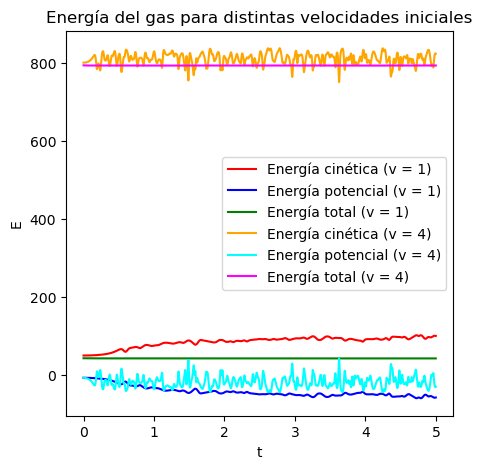

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Cargo los datos de las energías desde el fichero generado
Energias_v_1 = np.loadtxt("Energias_Lennard_Jones.txt")
Energias_v_4 = np.loadtxt("Energias_Lennard_Jones_v_4.txt")

# Extraigo las energías cinética, potencial y total hasta t = 5
E_cinetica_v_1 = Energias_v_1[:2500, 0]
E_potencial_v_1 = Energias_v_1[:2500, 1]
E_total_v_1 = Energias_v_1[:2500, 2]

E_cinetica_v_4 = Energias_v_4[:2500, 0]
E_potencial_v_4 = Energias_v_4[:2500, 1]
E_total_v_4 = Energias_v_4[:2500, 2]

# Creo un array de tiempo
t = np.arange(0, 2500) * 0.002

# Creo la figura para la gráfica
fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xlabel("t")
ax.set_ylabel("E")
ax.set_title("Energía del gas para distintas velocidades iniciales")

ax.plot(t, E_cinetica_v_1, label = r"Energía cinética (v = 1)", color = "red")
ax.plot(t, E_potencial_v_1, label = r"Energía potencial (v = 1)", color = "blue")
ax.plot(t, E_total_v_1, label = r"Energía total (v = 1)", color = "green")

ax.plot(t, E_cinetica_v_4, label = r"Energía cinética (v = 4)", color = "orange")
ax.plot(t, E_potencial_v_4, label = r"Energía potencial (v = 4)", color = "cyan")
ax.plot(t, E_total_v_4, label = r"Energía total (v = 4)", color = "magenta")

ax.legend(loc = "center right")

#Guardo la figura
fig.savefig("Energias_Lennard_Jones_distintas_v.png", dpi = 300)

plt.show()

Calculo la temperatura que se obtiene a partir del teorema de equipartición.

\begin{equation}
\nonumber
k_B T = \frac{m}{2} \langle v_x^2 + v_y^2 \rangle
\end{equation}

Grafico el histograma del módulo de velocidades en t=250. Compruebo que el histograma se ajusta a una distribución de Maxwell con la temperatura calculada a partir del teorema de equipartición:

\begin{equation}
\nonumber
P(v) = \bigg(\frac{m}{k_B T}\bigg) v e^{-\frac{mv^2}{2k_B T}}
\end{equation}

Grafico los histogramas en t = 250 para $v_x$ y $v_y$. Compruebo que los histogramas se ajustan a la siguiente Gaussiana:

\begin{equation}
\nonumber
P(v_x) = \sqrt{\frac{m}{2\pi k_B T}}e^{-\frac{mv_x^2}{2k_B T}}
\end{equation}


Temperatura media del sistema con v = 1:
1.022839e+00
Temperatura media del sistema con v = 4:
8.110577e+00


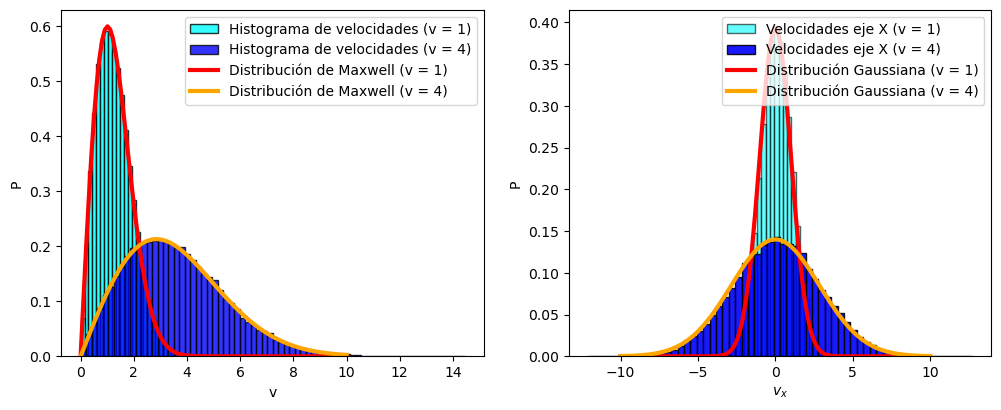

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Extraigo los datos de las posiciones y velocidades de los ficheros
Velocidades = np.loadtxt("Velocidades_Atomos.txt")
Velocidades_v_4 = np.loadtxt("Velocidades_Atomos_v_4.txt")

# Extraigo las velocidades v_x e v_y de cada átomo desde los 100 segundos hasta los 250 segundos 
v_x = Velocidades[50000:, 0::2]
v_y = Velocidades[50000:, 1::2]

v_x_4 = Velocidades_v_4[50000:, 0::2]
v_y_4 = Velocidades_v_4[50000:, 1::2]

# Hago la media sobre las columnas, es decir, sobre los átomos, para obtener la temperatura en cada instante de tiempo 
T = 0.5 * np.mean(v_x**2 + v_y**2, axis = 1) 
T_v_4 = 0.5 * np.mean(v_x_4**2 + v_y_4**2, axis = 1)

# Hago la media sobre el intervalo temporal de 100 a 250 segundos
T_medio = np.mean(T)
T_v_4_medio = np.mean(T_v_4)

print(f"Temperatura media del sistema con v = 1:\n{T_medio:e}")
print(f"Temperatura media del sistema con v = 4:\n{T_v_4_medio:e}")

# Hago los histogramas y los ajusto a las distribuciones

# Calculo el módulo de la velocidad de cada átomo entre t = 100 y t=250 segundos
v = np.sqrt(v_x**2 + v_y**2)
v_4 = np.sqrt(v_x_4**2 + v_y_4**2)

# Transformo la matriz v en un vector
v = v.ravel()
v_x = v_x.ravel()
v_y = v_y.ravel()

v_4 = v_4.ravel()
v_x_4 = v_x_4.ravel()
v_y_4 = v_y_4.ravel()

# Genero un array con la distribución de Maxwell con la T obtenida con el teorema de equipartición
def Maxwell(v, T):
    return (1.0 / T) * v * np.exp(-v**2 / (2.0 * T))

v_teo = np.linspace(0, 10, 100)
dist_Maxwell = Maxwell(v_teo, T_medio)
dist_Maxwell_v_4 = Maxwell(v_teo, T_v_4_medio)

# Genero un array con la distribución Gaussiana
def Gaussiana(v, T):
    return np.sqrt(1.0 / (2.0 * np.pi * T)) * np.exp(-v**2 / (2.0 * T))

v_eje_teo = np.linspace(-10, 10, 100)
dist_Gaussiana = Gaussiana(v_eje_teo, T_medio)
dist_Gaussiana_v_4 = Gaussiana(v_eje_teo, T_v_4_medio)

# Hago un histograma del módulo de la velocidad de los átomos en t=250 segundos
fig, ax = plt.subplots(1,2, figsize=(12, 4.5))

ax[0].hist(v, bins = 30, density = True, alpha = 0.8, edgecolor="black", label = "Histograma de velocidades (v = 1)", color = "cyan")
ax[0].hist(v_4, bins = 70, density = True, alpha = 0.8, edgecolor="black", label = "Histograma de velocidades (v = 4)", color = "blue")
ax[0].plot(v_teo, dist_Maxwell, label = "Distribución de Maxwell (v = 1)", color = "red", linewidth = 3)
ax[0].plot(v_teo, dist_Maxwell_v_4, label = "Distribución de Maxwell (v = 4)", color = "orange", linewidth = 3)
ax[0].set_xlabel("v")
ax[0].set_ylabel("P")
ax[0].legend()

ax[1].hist(v_x, bins = 30, density = True, alpha = 0.6, edgecolor="black", label = "Velocidades eje X (v = 1)", color = "cyan")
ax[1].hist(v_x_4, bins = 60, density = True, alpha = 0.9, edgecolor="black", label = "Velocidades eje X (v = 4)", color = "blue")
ax[1].plot(v_eje_teo, dist_Gaussiana, label = "Distribución Gaussiana (v = 1)", color = "red", linewidth = 3)
ax[1].plot(v_eje_teo, dist_Gaussiana_v_4, label = "Distribución Gaussiana (v = 4)", color = "orange", linewidth = 3)
ax[1].set_xlabel(r"$v_x$")
ax[1].set_ylabel("P")
ax[1].legend()

fig.savefig("Histograma_velocidades_Lennard_Jones_distintas_v.png", dpi = 300)

Velocidad inicial en el eje Y nula.

Temperatura media del sistema en equilibrio:
8.986692e-01


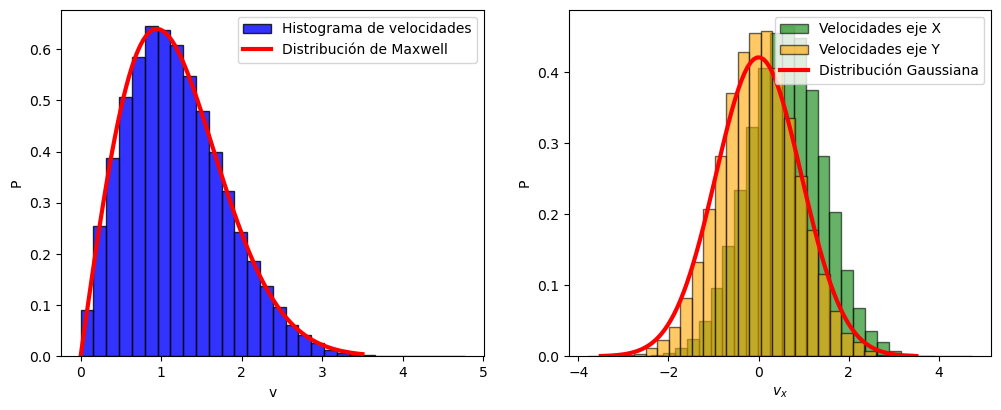

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Extraigo los datos de las posiciones y velocidades de los ficheros
Velocidades = np.loadtxt("Velocidades_Atomos_v_x.txt")

# Extraigo las velocidades v_x e v_y de cada átomo desde los 100 segundos hasta los 250 segundos 
v_x = Velocidades[50000:, 0::2]
v_y = Velocidades[50000:, 1::2]

# Hago la media sobre las columnas, es decir, sobre los átomos, para obtener la temperatura en cada instante de tiempo 
T = 0.5 * np.mean(v_x**2 + v_y**2, axis = 1) 

# Hago la media sobre el intervalo temporal de 100 a 250 segundos
T_medio = np.mean(T)

print(f"Temperatura media del sistema en equilibrio:\n{T_medio:e}")

# Hago los histogramas y los ajusto a las distribuciones

# Calculo el módulo de la velocidad de cada átomo entre t = 100 y t=250 segundos
v = np.sqrt(v_x**2 + v_y**2)

# Transformo la matriz v en un vector
v = v.ravel()
v_x = v_x.ravel()
v_y = v_y.ravel()

# Genero un array con la distribución de Maxwell con la T obtenida con el teorema de equipartición
def Maxwell(v, T):
    return (1.0 / T) * v * np.exp(-v**2 / (2.0 * T))

v_teo = np.linspace(0, 3.5, 100)
dist_Maxwell = Maxwell(v_teo, T_medio)

# Genero un array con la distribución Gaussiana
def Gaussiana(v, T):
    return np.sqrt(1.0 / (2.0 * np.pi * T)) * np.exp(-v**2 / (2.0 * T))

v_eje_teo = np.linspace(-3.5, 3.5, 100)
dist_Gaussiana = Gaussiana(v_eje_teo, T_medio)

# Hago un histograma del módulo de la velocidad de los átomos en t=250 segundos
fig, ax = plt.subplots(1,2, figsize=(12, 4.5))

ax[0].hist(v, bins = 30, density = True, alpha = 0.8, edgecolor="black", label = "Histograma de velocidades", color = "blue")
ax[0].plot(v_teo, dist_Maxwell, label = "Distribución de Maxwell", color = "red", linewidth = 3)
ax[0].set_xlabel("v")
ax[0].set_ylabel("P")
ax[0].legend()

ax[1].hist(v_x, bins = 30, density = True, alpha = 0.6, edgecolor="black", label = "Velocidades eje X", color = "green")
ax[1].hist(v_y, bins = 30, density = True, alpha = 0.6, edgecolor="black", label = "Velocidades eje Y", color = "orange")
ax[1].plot(v_eje_teo, dist_Gaussiana, label = "Distribución Gaussiana", color = "red", linewidth = 3)
ax[1].set_xlabel(r"$v_x$")
ax[1].set_ylabel("P")
ax[1].legend()

fig.savefig("Histograma_velocidades_Lennard_Jones_v_x.png", dpi = 300)
